In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('train.csv')

# Check available columns
print("Available columns in dataset:", df.columns)

# Select features and target
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage']
target = 'Workout_Type'  # Replace 'Diabetes' with an existing column, e.g., 'Workout_Type'

if target not in df.columns:
    raise ValueError(f"Target column '{target}' does not exist in the dataset.")

X = df[features]
y = df[target]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Available columns in dataset: Index(['Age', 'Gender', 'Weight (kg)', 'P1: Weight_Scaled', 'Height (m)',
       'Max_BPM', 'Avg_BPM', 'R1: Avg_BPM_Scaled', 'Resting_BPM',
       'Session_Duration (hours)', 'Q1: Session_Duration_Scaled',
       'Calories_Burned', 'Workout_Type', 'L1 = Yoga', 'M1 = HIIT',
       'N1 = Cardio', 'O1 = Strength', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI', 'Random'],
      dtype='object')
Accuracy: 0.22
Classification Report:
              precision    recall  f1-score   support

      Cardio       0.29      0.26      0.28        42
        HIIT       0.20      0.24      0.22        41
    Strength       0.23      0.26      0.24        38
        Yoga       0.17      0.11      0.14        35

    accuracy                           0.22       156
   macro avg       0.22      0.22      0.22       156
weighted avg       0.22      0.22      0.22       156



In [6]:
import pandas as pd

# Đọc file CSV
file_path = "gym_members_exercise_tracking(lamsach).csv"
df = pd.read_csv("gym_members_exercise_tracking(lamsach).csv", header=2)
df = df.dropna(how='all')  # Loại bỏ các dòng toàn giá trị NaN
df = df[df['Age'].notna()]  # Giữ lại các dòng có giá trị hợp lệ trong cột 'Age'

# Encode target column
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Workout_Type'] = label_encoder.fit_transform(df['Workout_Type'])

# Save cleaned data
cleaned_file_path = "gym_members_exercise_tracking_cleaned.csv"
df.to_csv(cleaned_file_path, index=False)
# Thêm các cột bài tập
df['Yoga'] = (df['Workout_Type'] == 'Yoga').astype(int)
df['Strength'] = (df['Workout_Type'] == 'Strength').astype(int)
df['HIIT'] = (df['Workout_Type'] == 'HIIT').astype(int)
df['Cardio'] = (df['Workout_Type'] == 'Cardio').astype(int)

# Kiểm tra kết quả
print(df[['Workout_Type', 'Yoga', 'Strength', 'HIIT', 'Cardio']].head())

# Lưu dataset đã chỉnh sửa
df.to_csv(cleaned_file_path, index=False)
print("Dataset đã được cập nhật và lưu lại.")
print(f"Dữ liệu đã được làm sạch và lưu tại: {cleaned_file_path}")

   Workout_Type  Yoga  Strength  HIIT  Cardio
0             3     0         0     0       0
1             1     0         0     0       0
2             0     0         0     0       0
3             2     0         0     0       0
4             2     0         0     0       0
Dataset đã được cập nhật và lưu lại.
Dữ liệu đã được làm sạch và lưu tại: gym_members_exercise_tracking_cleaned.csv


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pickle

# Load dataset
df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')
print("Các cột trong tập dữ liệu:", df.columns.tolist())

# Kiểm tra dữ liệu
if df.isnull().values.any():
    print("Dữ liệu chứa giá trị thiếu. Vui lòng làm sạch dữ liệu trước khi huấn luyện.")
    df = df.dropna()

# Select features and target
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage']
target = 'Calories_Burned'  # Dự đoán số calo

# Kiểm tra cột mục tiêu
if target not in df.columns:
    raise ValueError(f"Cột mục tiêu '{target}' không tồn tại trong dữ liệu. Các cột hiện có: {df.columns.tolist()}")

# Kiểm tra xem các feature có đầy đủ không
missing_cols = [col for col in features if col not in df.columns]
if missing_cols:
    raise ValueError(f"Các cột sau không tồn tại trong dữ liệu: {missing_cols}")

# In tương quan
print("Tương quan giữa các đặc trưng và Calories_Burned:")
print(df[features + [target]].corr()[target])

# Split dataset
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# In độ quan trọng đặc trưng
print("Feature Importances:")
for feature, importance in zip(features, rf_regressor.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# Lưu mô hình
try:
    with open('rf_calories_model.pkl', 'wb') as model_file:
        pickle.dump(rf_regressor, model_file)
    print("Mô hình đã được lưu thành công vào file 'rf_calories_model.pkl'")
except Exception as e:
    print(f"Lỗi khi lưu mô hình: {str(e)}")

Các cột trong tập dữ liệu: ['Age', 'Gender', 'Weight (kg)', 'P1: Weight_Scaled', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'R1: Avg_BPM_Scaled', 'Resting_BPM', 'Session_Duration (hours)', 'Q1: Session_Duration_Scaled', 'Calories_Burned', 'Workout_Type', 'L1 = Yoga', 'M1 = HIIT', 'N1 = Cardio', 'O1 = Strength', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Yoga', 'Strength', 'HIIT', 'Cardio']
Tương quan giữa các đặc trưng và Calories_Burned:
Age                             -0.154679
Weight (kg)                      0.095443
BMI                              0.059761
Workout_Frequency (days/week)    0.576150
Fat_Percentage                  -0.597615
Calories_Burned                  1.000000
Name: Calories_Burned, dtype: float64
Mean Squared Error: 43846.60
Feature Importances:
Age: 0.1293
Weight (kg): 0.1252
BMI: 0.1274
Workout_Frequency (days/week): 0.0502
Fat_Percentage: 0.5679
Mô hình đã được lưu thành công vào file 'rf_calories_model

Mean Squared Error: 43846.60

Feature Importances:
                         Feature  Importance
4                 Fat_Percentage    0.567916
0                            Age    0.129301
2                            BMI    0.127382
1                    Weight (kg)    0.125185
3  Workout_Frequency (days/week)    0.050217
✅ Mô hình đã được lưu.


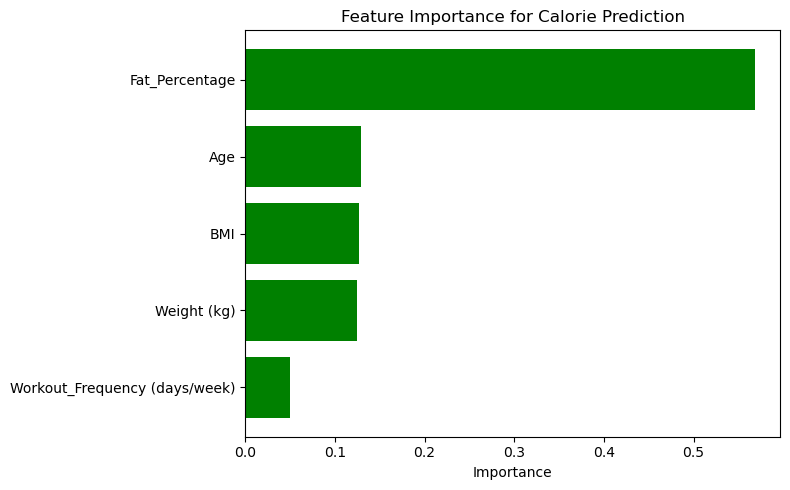

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pickle
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')

# Drop missing values if any
df = df.dropna()

# Chọn đặc trưng và mục tiêu
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage']
target = 'Calories_Burned'

# Kiểm tra tồn tại cột mục tiêu
if target not in df.columns:
    raise ValueError(f"Cột mục tiêu '{target}' không tồn tại.")

X = df[features]
y = df[target]

# Tách tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán & đánh giá
y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Hiển thị tầm quan trọng của các đặc trưng
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("\nFeature Importances:")
print(feature_importance_df)

# Lưu mô hình
with open('rf_calories_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("✅ Mô hình đã được lưu.")

# Vẽ biểu đồ trực quan
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='green')
plt.xlabel("Importance")
plt.title("Feature Importance for Calorie Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pickle

# Load dataset
df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')

# Kiểm tra và loại bỏ dòng thiếu dữ liệu
if df.isnull().values.any():
    print("Có dữ liệu thiếu. Đang tiến hành loại bỏ...")
    df = df.dropna()

# Kiểm tra xem cột cần thiết có tồn tại không
required_columns = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage', 'Session_Duration (hours)', 'Calories_Burned']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Thiếu cột: {missing_columns}")

# Chọn features và target
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage', 'Session_Duration (hours)']
target = 'Calories_Burned'

# Tách tập train/test
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Đánh giá
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Lưu model
with open("rf_calories_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("✅ Mô hình đã được huấn luyện và lưu thành công.")


Mean Squared Error: 11535.83
✅ Mô hình đã được huấn luyện và lưu thành công.


Mean Squared Error: 11535.83
Age: 0.0402
Weight (kg): 0.0305
BMI: 0.0271
Workout_Frequency (days/week): 0.0053
Fat_Percentage: 0.0499
Session_Duration (hours): 0.8469


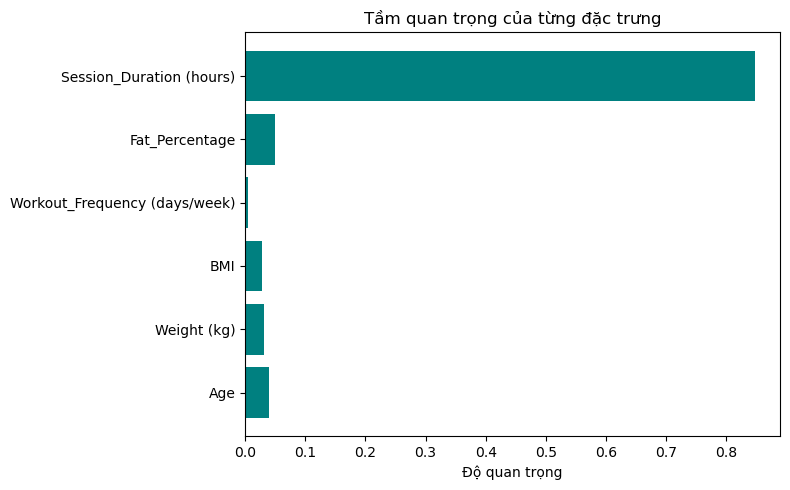

✅ Mô hình đã được huấn luyện và lưu thành công.


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pickle

# Load dataset
df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')

# Loại bỏ dòng thiếu dữ liệu
df = df.dropna()

# Kiểm tra cột cần thiết
required_columns = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 
                    'Fat_Percentage', 'Session_Duration (hours)', 'Calories_Burned']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Thiếu cột: {missing_columns}")

# Chọn đặc trưng và mục tiêu
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 
            'Fat_Percentage', 'Session_Duration (hours)']
target = 'Calories_Burned'

X = df[features]
y = df[target]

# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Kiểm tra độ quan trọng của đặc trưng
importances = rf_model.feature_importances_
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance:.4f}")

# Hiển thị biểu đồ
plt.figure(figsize=(8, 5))
plt.barh(features, importances, color='teal')
plt.xlabel('Độ quan trọng')
plt.title('Tầm quan trọng của từng đặc trưng')
plt.tight_layout()
plt.show()

# Lưu mô hình
with open("rf_calories_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("✅ Mô hình đã được huấn luyện và lưu thành công.")


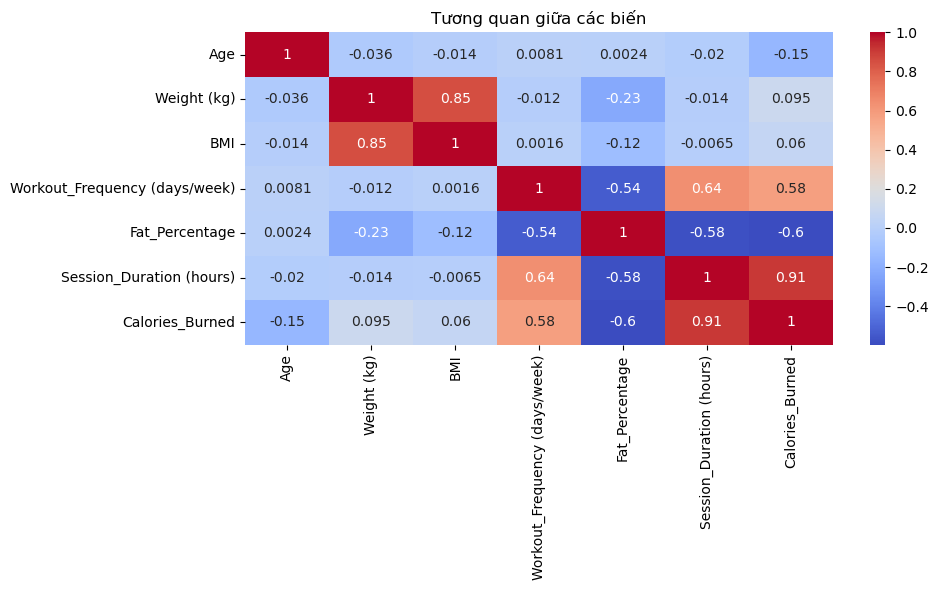

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ heatmap để xem mối tương quan
plt.figure(figsize=(10, 6))
correlation_matrix = df[features + ['Calories_Burned']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Tương quan giữa các biến")
plt.tight_layout()
plt.show()


Text(0.5, 1.0, ' Biểu đồ phân tán giữa Session_Duration và Calories_Burned (Scatter Plot)')

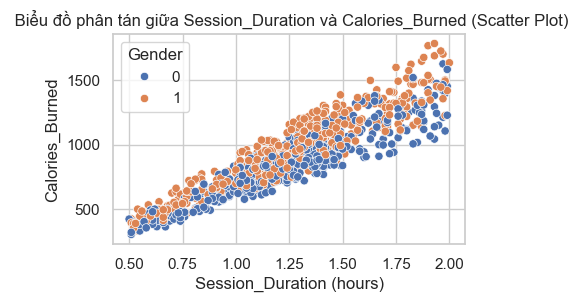

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
df = pd.read_csv("gym_members_exercise_tracking_cleaned.csv")

# Cấu hình chung cho biểu đồ
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
# ===== Biểu đồ 2: Scatter Plot - Session_Duration vs Calories_Burned =====
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x="Session_Duration (hours)", y="Calories_Burned", hue="Gender")
plt.title(" Biểu đồ phân tán giữa Session_Duration và Calories_Burned (Scatter Plot)")

C:\Users\Truc Nguyen\AppData\Local\Temp\ipykernel_15876\2113036649.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Avg_BPM_group')['Calories_Burned'].mean().reset_index()
C:\Users\Truc Nguyen\AppData\Local\Temp\ipykernel_15876\2113036649.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x='Avg_BPM_group', y='Calories_Burned', palette='viridis')


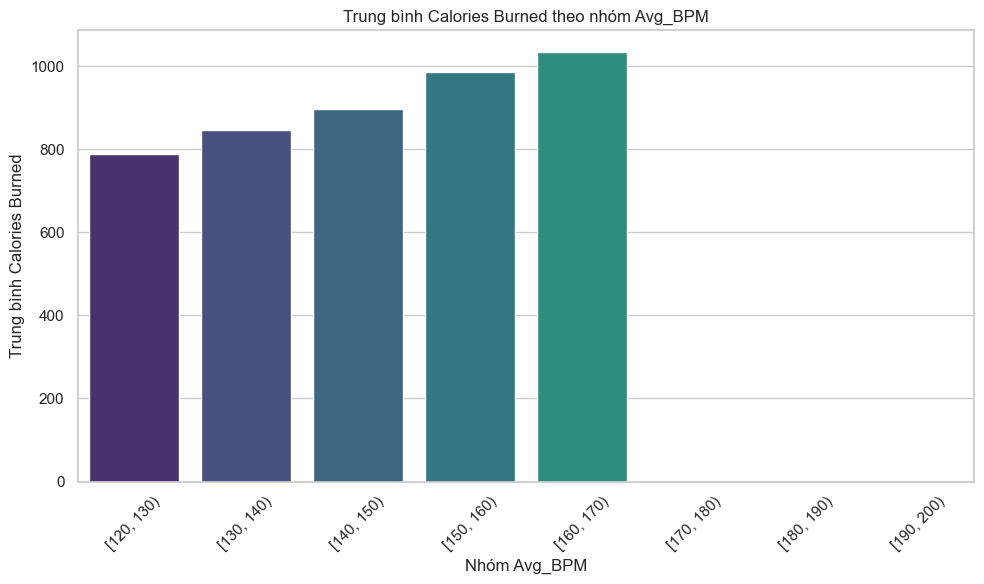

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv("gym_members_exercise_tracking_cleaned.csv")

# Chia Avg_BPM thành các nhóm (bins)
df['Avg_BPM_group'] = pd.cut(df['Avg_BPM'], bins=[120, 130, 140, 150, 160, 170, 180, 190, 200], right=False)

# Tính trung bình Calories_Burned cho từng nhóm
grouped = df.groupby('Avg_BPM_group')['Calories_Burned'].mean().reset_index()

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='Avg_BPM_group', y='Calories_Burned', palette='viridis')

plt.title("Trung bình Calories Burned theo nhóm Avg_BPM")
plt.xlabel("Nhóm Avg_BPM")
plt.ylabel("Trung bình Calories Burned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Truc Nguyen\AppData\Local\Temp\ipykernel_15876\661271336.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Workout_Type", y="Calories_Burned", palette="Set2", ci=None)
C:\Users\Truc Nguyen\AppData\Local\Temp\ipykernel_15876\661271336.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Workout_Type", y="Calories_Burned", palette="Set2", ci=None)


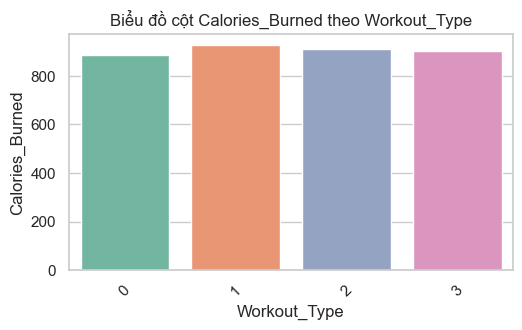

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
df = pd.read_csv("gym_members_exercise_tracking_cleaned.csv")

# Cấu hình chung cho biểu đồ
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# ===== Biểu đồ 4: Biểu đồ cột - Calories_Burned theo Workout_Type =====
plt.subplot(2, 2, 3)
sns.barplot(data=df, x="Workout_Type", y="Calories_Burned", palette="Set2", ci=None)
plt.title("Biểu đồ cột Calories_Burned theo Workout_Type")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


C:\Users\Truc Nguyen\AppData\Local\Temp\ipykernel_15876\2239448766.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Calories_Burned'], shade=True, color="skyblue")


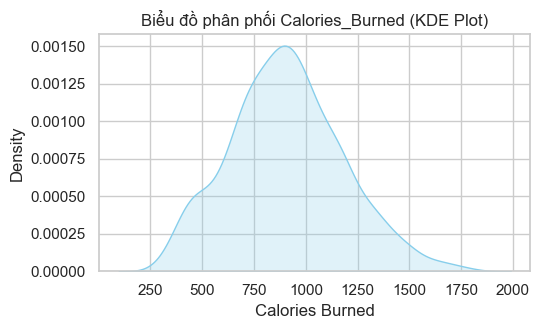

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
df = pd.read_csv("gym_members_exercise_tracking_cleaned.csv")

# Cấu hình chung cho biểu đồ
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# ===== Biểu đồ phân phối Calories_Burned (KDE Plot) =====
plt.subplot(2, 2, 4)
sns.kdeplot(df['Calories_Burned'], shade=True, color="skyblue")
plt.title("Biểu đồ phân phối Calories_Burned (KDE Plot)")
plt.xlabel("Calories Burned")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

      Cardio       0.67      0.67      0.67         3
    Strength       0.50      0.50      0.50         2
        Yoga       0.50      0.50      0.50         2

    accuracy                           0.57         7
   macro avg       0.56      0.56      0.56         7
weighted avg       0.57      0.57      0.57         7

Accuracy Score: 0.57


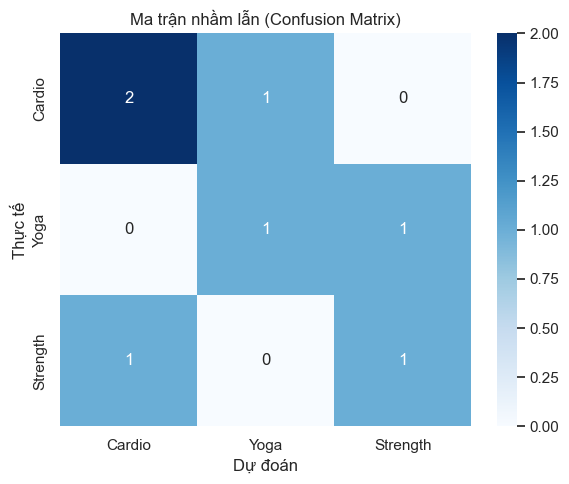

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Ví dụ dữ liệu thật và dự đoán (thay thế bằng dữ liệu thật của bạn)
y_true = ['Cardio', 'Strength', 'Cardio', 'Yoga', 'Strength', 'Cardio', 'Yoga']
y_pred = ['Cardio', 'Strength', 'Yoga', 'Yoga', 'Cardio', 'Cardio', 'Strength']

# ===== Hàm fusion: In ra các chỉ số đánh giá =====
def evaluate_model(y_true, y_pred):
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print(f"Accuracy Score: {accuracy_score(y_true, y_pred):.2f}")

# ===== Hàm matrix: Vẽ ma trận nhầm lẫn =====
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=list(set(y_true)))
    labels = list(set(y_true))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")
    plt.tight_layout()
    plt.show()

# Gọi hàm đánh giá và vẽ ma trận
evaluate_model(y_true, y_pred)
plot_confusion_matrix(y_true, y_pred)


<Figure size 600x500 with 0 Axes>

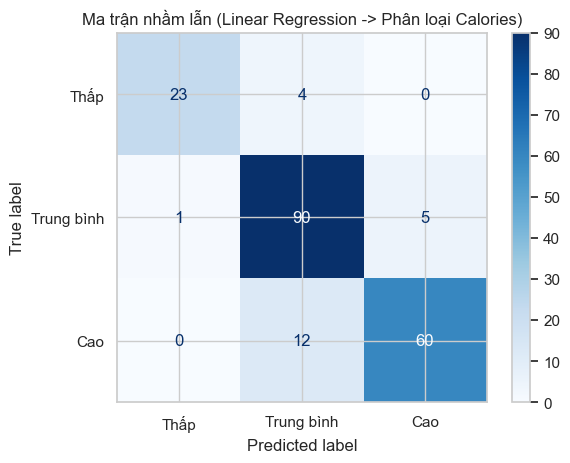

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Đọc dữ liệu
df = pd.read_csv("gym_members_exercise_tracking_cleaned.csv")

# Chọn biến đầu vào và đầu ra
X = df[['Avg_BPM', 'Session_Duration (hours)', 'Fat_Percentage']]
y = df['Calories_Burned']

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Chuyển đổi y_test và y_pred thành các nhóm
def categorize(cal):
    if cal < 600:
        return 'Thấp'
    elif cal < 1000:
        return 'Trung bình'
    else:
        return 'Cao'

y_test_cat = y_test.apply(categorize)
y_pred_cat = pd.Series(y_pred).apply(categorize)

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=['Thấp', 'Trung bình', 'Cao'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Thấp', 'Trung bình', 'Cao'])

# Hiển thị
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues')
plt.title("Ma trận nhầm lẫn (Linear Regression -> Phân loại Calories)")
plt.show()


<Figure size 600x500 with 0 Axes>

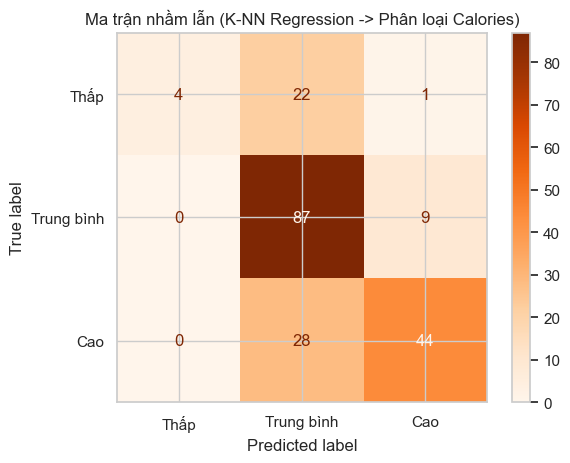

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("gym_members_exercise_tracking_cleaned.csv")

# Chọn biến đầu vào và đầu ra
X = df[['Avg_BPM', 'Session_Duration (hours)', 'Fat_Percentage']]
y = df['Calories_Burned']

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình KNN Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Chuyển đổi y_test và y_pred thành các nhóm (bins)
def categorize(cal):
    if cal < 600:
        return 'Thấp'
    elif cal < 1000:
        return 'Trung bình'
    else:
        return 'Cao'

y_test_cat = y_test.apply(categorize)
y_pred_cat = pd.Series(y_pred).apply(categorize)

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=['Thấp', 'Trung bình', 'Cao'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Thấp', 'Trung bình', 'Cao'])

# Hiển thị
plt.figure(figsize=(6, 5))
disp.plot(cmap='Oranges')
plt.title("Ma trận nhầm lẫn (K-NN Regression -> Phân loại Calories)")
plt.show()


✅ Mean Squared Error: 11535.83

📌 Feature Importances:
Session_Duration (hours)         0.846943
Fat_Percentage                   0.049888
Age                              0.040217
Weight (kg)                      0.030536
BMI                              0.027119
Workout_Frequency (days/week)    0.005297
dtype: float64
📊 Biểu đồ đã lưu vào feature_importance.png
✅ Mô hình đã được huấn luyện và lưu thành công vào 'rf_calories_model.pkl'


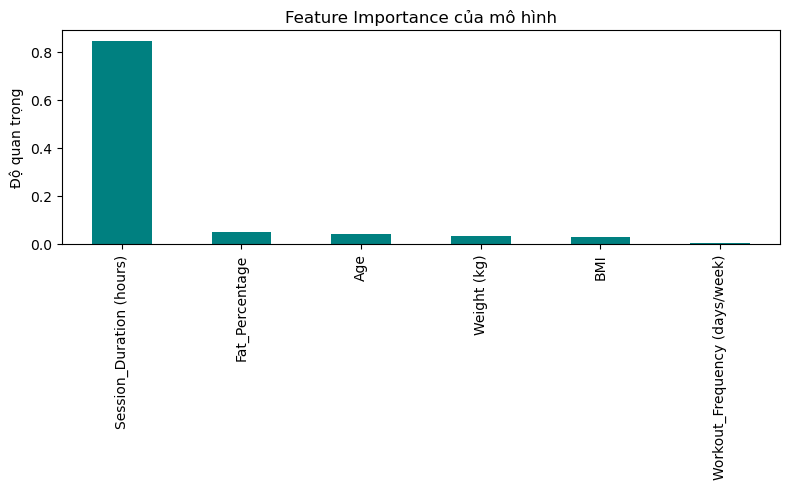

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pickle
import matplotlib.pyplot as plt

# Đọc dữ liệu từ file CSV
df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')

# Kiểm tra và xử lý dữ liệu thiếu
if df.isnull().values.any():
    print("⚠️ Có dữ liệu thiếu. Đang loại bỏ...")
    df = df.dropna()

# Các cột cần thiết
required_columns = [
    'Age', 
    'Weight (kg)', 
    'BMI', 
    'Workout_Frequency (days/week)', 
    'Fat_Percentage', 
    'Session_Duration (hours)', 
    'Calories_Burned'
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Thiếu cột: {missing_columns}")

# Tách features và target
features = [
    'Age', 
    'Weight (kg)', 
    'BMI', 
    'Workout_Frequency (days/week)', 
    'Fat_Percentage', 
    'Session_Duration (hours)'
]
target = 'Calories_Burned'

X = df[features]
y = df[target]

# Chia dữ liệu thành train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"✅ Mean Squared Error: {mse:.2f}")

# In độ quan trọng của các đặc trưng
importances = rf_model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)
print("\n📌 Feature Importances:")
print(feature_importance)

# Vẽ biểu đồ và lưu ảnh
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='teal')
plt.title('Feature Importance của mô hình')
plt.ylabel('Độ quan trọng')
plt.tight_layout()
plt.savefig("feature_importance.png")
print("📊 Biểu đồ đã lưu vào feature_importance.png")

# Lưu mô hình
with open("rf_calories_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("✅ Mô hình đã được huấn luyện và lưu thành công vào 'rf_calories_model.pkl'")


In [11]:
correlation = df[features + [target]].corr()[target]
print("Tương quan giữa các đặc trưng và Calories_Burned:")
print(correlation)


Tương quan giữa các đặc trưng và Calories_Burned:
Age                             -0.154679
Weight (kg)                      0.095443
BMI                              0.059761
Workout_Frequency (days/week)    0.576150
Fat_Percentage                  -0.597615
Session_Duration (hours)         0.908140
Calories_Burned                  1.000000
Name: Calories_Burned, dtype: float64


In [12]:
print(df[['Age', 'Weight (kg)', 'Calories_Burned']].head(10))


   Age  Weight (kg)  Calories_Burned
0   56         88.3             1313
1   46         74.9              883
2   32         68.1              677
3   25         53.2              532
4   38         46.1              556
5   56         58.0             1116
6   36         70.3             1385
7   40         69.7              895
8   28        121.7              719
9   28        101.8              808


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle

# Load dataset
try:
    df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')
except FileNotFoundError:
    raise FileNotFoundError("Không tìm thấy file dữ liệu 'gym_members_exercise_tracking_cleaned.csv'.")

# Xử lý giá trị thiếu
if df.isnull().values.any():
    print("Dữ liệu chứa giá trị thiếu. Đang loại bỏ các dòng bị thiếu...")
    df = df.dropna()

# Feature và target
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage', 'Session_Duration (hours)']
target = 'Calories_Burned'

if target not in df.columns:
    raise ValueError(f"Cột mục tiêu '{target}' không tồn tại. Các cột hiện có: {df.columns.tolist()}")

# Tính tương quan
correlation = df[features + [target]].corr()[target]
print("Tương quan giữa các đặc trưng và Calories_Burned:")
print(correlation)

# Tách dữ liệu
X = df[features]
y = df[target]

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lưu scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán
y_pred = rf.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

# Tầm quan trọng của đặc trưng
print("Tầm quan trọng của từng đặc trưng:")
for f, imp in zip(features, rf.feature_importances_):
    print(f"{f}: {imp:.4f}")

# Lưu mô hình
with open('rf_calories_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("✅ Mô hình đã lưu tại 'rf_calories_model.pkl'")

Tương quan giữa các đặc trưng và Calories_Burned:
Age                             -0.154679
Weight (kg)                      0.095443
BMI                              0.059761
Workout_Frequency (days/week)    0.576150
Fat_Percentage                  -0.597615
Session_Duration (hours)         0.908140
Calories_Burned                  1.000000
Name: Calories_Burned, dtype: float64
Mean Squared Error: 11556.65
R² Score: 0.86
Tầm quan trọng của từng đặc trưng:
Age: 0.0402
Weight (kg): 0.0305
BMI: 0.0271
Workout_Frequency (days/week): 0.0053
Fat_Percentage: 0.0499
Session_Duration (hours): 0.8469
✅ Mô hình đã lưu tại 'rf_calories_model.pkl'


In [2]:
print("\n📊 Min và Max của từng đặc trưng:")
for col in features:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")



📊 Min và Max của từng đặc trưng:
Age: min = 18, max = 59
Weight (kg): min = 40.0, max = 129.9
BMI: min = 12.32, max = 49.84
Workout_Frequency (days/week): min = 2, max = 5
Fat_Percentage: min = 10.0, max = 35.0
Session_Duration (hours): min = 0.5, max = 2.0


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle

# Load dataset
try:
    df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')
except FileNotFoundError:
    raise FileNotFoundError("❌ Không tìm thấy file dữ liệu 'gym_members_exercise_tracking_cleaned.csv'.")

# Xử lý giá trị thiếu
if df.isnull().values.any():
    print("⚠️ Dữ liệu chứa giá trị thiếu. Đang loại bỏ các dòng bị thiếu...")
    df = df.dropna()

# Các cột đặc trưng và mục tiêu
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage', 'Session_Duration (hours)']
target = 'Calories_Burned'

# Kiểm tra tồn tại cột mục tiêu
if target not in df.columns:
    raise ValueError(f"❌ Cột mục tiêu '{target}' không tồn tại. Các cột hiện có: {df.columns.tolist()}")

# In khoảng giá trị đầu vào (giúp validate input ở front-end)
print("\n📊 Ngưỡng giá trị đầu vào (min-max):")
for col in features:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

# Tính tương quan với Calories_Burned
correlation = df[features + [target]].corr()[target]
print("\n📈 Tương quan giữa các đặc trưng và Calories_Burned:")
print(correlation)

# Tách đặc trưng và nhãn
X = df[features]
y = df[target]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lưu scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Đã lưu scaler tại 'scaler.pkl'")

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = rf.predict(X_test)
print(f"\n📉 Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"📈 R² Score: {r2_score(y_test, y_pred):.2f}")

# In tầm quan trọng của các đặc trưng
print("\n📌 Tầm quan trọng của từng đặc trưng:")
for f, imp in zip(features, rf.feature_importances_):
    print(f"{f}: {imp:.4f}")

# Lưu mô hình
with open('rf_calories_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("\n✅ Mô hình đã lưu tại 'rf_calories_model.pkl'")



📊 Ngưỡng giá trị đầu vào (min-max):
Age: min = 18, max = 59
Weight (kg): min = 40.0, max = 129.9
BMI: min = 12.32, max = 49.84
Workout_Frequency (days/week): min = 2, max = 5
Fat_Percentage: min = 10.0, max = 35.0
Session_Duration (hours): min = 0.5, max = 2.0

📈 Tương quan giữa các đặc trưng và Calories_Burned:
Age                             -0.154679
Weight (kg)                      0.095443
BMI                              0.059761
Workout_Frequency (days/week)    0.576150
Fat_Percentage                  -0.597615
Session_Duration (hours)         0.908140
Calories_Burned                  1.000000
Name: Calories_Burned, dtype: float64

✅ Đã lưu scaler tại 'scaler.pkl'

📉 Mean Squared Error: 11556.65
📈 R² Score: 0.86

📌 Tầm quan trọng của từng đặc trưng:
Age: 0.0402
Weight (kg): 0.0305
BMI: 0.0271
Workout_Frequency (days/week): 0.0053
Fat_Percentage: 0.0499
Session_Duration (hours): 0.8469

✅ Mô hình đã lưu tại 'rf_calories_model.pkl'


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle

# Load dataset
try:
    df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')
except FileNotFoundError:
    raise FileNotFoundError("❌ Không tìm thấy file dữ liệu 'gym_members_exercise_tracking_cleaned.csv'.")

# Xử lý giá trị thiếu
if df.isnull().values.any():
    print("⚠️ Dữ liệu chứa giá trị thiếu. Đang loại bỏ các dòng bị thiếu...")
    df = df.dropna()

# ✅ Mã hóa giới tính: chuyển cột 'Gender' thành dạng số
if 'Gender' not in df.columns:
    raise ValueError("❌ Thiếu cột 'Gender' trong dữ liệu.")

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
if df['Gender'].isnull().any():
    raise ValueError("❌ Giá trị giới tính không hợp lệ. Chỉ chấp nhận 'Male' hoặc 'Female'.")

# Các cột đặc trưng và mục tiêu
features = ['Age', 'Gender', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage', 'Session_Duration (hours)']
target = 'Calories_Burned'

# Kiểm tra tồn tại cột mục tiêu
if target not in df.columns:
    raise ValueError(f"❌ Cột mục tiêu '{target}' không tồn tại. Các cột hiện có: {df.columns.tolist()}")

# In khoảng giá trị đầu vào (giúp validate input ở front-end)
print("\n📊 Ngưỡng giá trị đầu vào (min-max):")
for col in features:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

# Tính tương quan với Calories_Burned
correlation = df[features + [target]].corr()[target]
print("\n📈 Tương quan giữa các đặc trưng và Calories_Burned:")
print(correlation)

# Tách đặc trưng và nhãn
X = df[features]
y = df[target]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lưu scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Đã lưu scaler tại 'scaler.pkl'")

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = rf.predict(X_test)
print(f"\n📉 Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"📈 R² Score: {r2_score(y_test, y_pred):.2f}")

# In tầm quan trọng của các đặc trưng
print("\n📌 Tầm quan trọng của từng đặc trưng:")
for f, imp in zip(features, rf.feature_importances_):
    print(f"{f}: {imp:.4f}")

# Lưu mô hình
with open('rf_calories_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("\n✅ Mô hình đã lưu tại 'rf_calories_model.pkl'")



📊 Ngưỡng giá trị đầu vào (min-max):
Age: min = 18, max = 59
Gender: min = 0, max = 1
Weight (kg): min = 40.0, max = 129.9
BMI: min = 12.32, max = 49.84
Workout_Frequency (days/week): min = 2, max = 5
Fat_Percentage: min = 10.0, max = 35.0
Session_Duration (hours): min = 0.5, max = 2.0

📈 Tương quan giữa các đặc trưng và Calories_Burned:
Age                             -0.154679
Gender                           0.150646
Weight (kg)                      0.095443
BMI                              0.059761
Workout_Frequency (days/week)    0.576150
Fat_Percentage                  -0.597615
Session_Duration (hours)         0.908140
Calories_Burned                  1.000000
Name: Calories_Burned, dtype: float64

✅ Đã lưu scaler tại 'scaler.pkl'

📉 Mean Squared Error: 11170.51
📈 R² Score: 0.87

📌 Tầm quan trọng của từng đặc trưng:
Age: 0.0394
Gender: 0.0135
Weight (kg): 0.0270
BMI: 0.0242
Workout_Frequency (days/week): 0.0052
Fat_Percentage: 0.0426
Session_Duration (hours): 0.8480

✅ Mô hình đ

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle

# Load dataset
try:
    df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')
except FileNotFoundError:
    raise FileNotFoundError("❌ Không tìm thấy file dữ liệu 'gym_members_exercise_tracking_cleaned.csv'.")

# Xử lý giá trị thiếu
if df.isnull().values.any():
    print("⚠️ Dữ liệu chứa giá trị thiếu. Đang loại bỏ các dòng bị thiếu...")
    df = df.dropna()

# Các cột đặc trưng và mục tiêu
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage', 'Session_Duration (hours)', 'Gender']
target = 'Calories_Burned'

# Kiểm tra tồn tại cột mục tiêu
if target not in df.columns:
    raise ValueError(f"❌ Cột mục tiêu '{target}' không tồn tại. Các cột hiện có: {df.columns.tolist()}")

# In khoảng giá trị đầu vào (giúp validate input ở front-end)
print("\n📊 Ngưỡng giá trị đầu vào (min-max):")
for col in features:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

# Tính tương quan với Calories_Burned
correlation = df[features + [target]].corr()[target]
print("\n📈 Tương quan giữa các đặc trưng và Calories_Burned:")
print(correlation)

# Tách đặc trưng và nhãn
X = df[features]
y = df[target]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lưu scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Đã lưu scaler tại 'scaler.pkl'")

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = rf.predict(X_test)
print(f"\n📉 Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"📈 R² Score: {r2_score(y_test, y_pred):.2f}")

# In tầm quan trọng của các đặc trưng
print("\n📌 Tầm quan trọng của từng đặc trưng:")
for f, imp in zip(features, rf.feature_importances_):
    print(f"{f}: {imp:.4f}")

# Lưu mô hình
with open('rf_calories_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("\n✅ Mô hình đã lưu tại 'rf_calories_model.pkl'")



📊 Ngưỡng giá trị đầu vào (min-max):
Age: min = 18, max = 59
Weight (kg): min = 40.0, max = 129.9
BMI: min = 12.32, max = 49.84
Workout_Frequency (days/week): min = 2, max = 5
Fat_Percentage: min = 10.0, max = 35.0
Session_Duration (hours): min = 0.5, max = 2.0
Gender: min = 0, max = 1

📈 Tương quan giữa các đặc trưng và Calories_Burned:
Age                             -0.154679
Weight (kg)                      0.095443
BMI                              0.059761
Workout_Frequency (days/week)    0.576150
Fat_Percentage                  -0.597615
Session_Duration (hours)         0.908140
Gender                           0.150646
Calories_Burned                  1.000000
Name: Calories_Burned, dtype: float64

✅ Đã lưu scaler tại 'scaler.pkl'

📉 Mean Squared Error: 11058.55
📈 R² Score: 0.87

📌 Tầm quan trọng của từng đặc trưng:
Age: 0.0395
Weight (kg): 0.0270
BMI: 0.0243
Workout_Frequency (days/week): 0.0052
Fat_Percentage: 0.0424
Session_Duration (hours): 0.8481
Gender: 0.0135

✅ Mô hình đ

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle

# Load dataset
try:
    df = pd.read_csv('gym_members_exercise_tracking_cleaned.csv')
except FileNotFoundError:
    raise FileNotFoundError("❌ Không tìm thấy file dữ liệu 'gym_members_exercise_tracking_cleaned.csv'.")

# Xử lý giá trị thiếu
if df.isnull().values.any():
    print("⚠️ Dữ liệu chứa giá trị thiếu. Đang loại bỏ các dòng bị thiếu...")
    df = df.dropna()

# Các cột đặc trưng và mục tiêu
features = ['Age', 'Weight (kg)', 'BMI', 'Workout_Frequency (days/week)', 'Fat_Percentage', 'Session_Duration (hours)', 'Gender']
target = 'Calories_Burned'

# Kiểm tra tồn tại cột mục tiêu
if target not in df.columns:
    raise ValueError(f"❌ Cột mục tiêu '{target}' không tồn tại. Các cột hiện có: {df.columns.tolist()}")

# In khoảng giá trị đầu vào (giúp validate input ở front-end)
print("\n📊 Ngưỡng giá trị đầu vào (min-max):")
for col in features:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

# Tính tương quan với Calories_Burned
correlation = df[features + [target]].corr()[target]
print("\n📈 Tương quan giữa các đặc trưng và Calories_Burned:")
print(correlation)

# Tách đặc trưng và nhãn
X = df[features]
y = df[target]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lưu scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Đã lưu scaler tại 'scaler.pkl'")

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = rf.predict(X_test)
print(f"\n📉 Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"📈 R² Score: {r2_score(y_test, y_pred):.2f}")

# In tầm quan trọng của các đặc trưng
print("\n📌 Tầm quan trọng của từng đặc trưng:")
for f, imp in zip(features, rf.feature_importances_):
    print(f"{f}: {imp:.4f}")

# Lưu mô hình
with open('rf_calories_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("\n✅ Mô hình đã lưu tại 'rf_calories_model.pkl'")


📊 Ngưỡng giá trị đầu vào (min-max):
Age: min = 18, max = 59
Weight (kg): min = 40.0, max = 129.9
BMI: min = 12.32, max = 49.84
Workout_Frequency (days/week): min = 2, max = 5
Fat_Percentage: min = 10.0, max = 35.0
Session_Duration (hours): min = 0.5, max = 2.0
Gender: min = 0, max = 1

📈 Tương quan giữa các đặc trưng và Calories_Burned:
Age                             -0.154679
Weight (kg)                      0.095443
BMI                              0.059761
Workout_Frequency (days/week)    0.576150
Fat_Percentage                  -0.597615
Session_Duration (hours)         0.908140
Gender                           0.150646
Calories_Burned                  1.000000
Name: Calories_Burned, dtype: float64

✅ Đã lưu scaler tại 'scaler.pkl'

📉 Mean Squared Error: 11058.55
📈 R² Score: 0.87

📌 Tầm quan trọng của từng đặc trưng:
Age: 0.0395
Weight (kg): 0.0270
BMI: 0.0243
Workout_Frequency (days/week): 0.0052
Fat_Percentage: 0.0424
Session_Duration (hours): 0.8481
Gender: 0.0135

✅ Mô hình đ